Utilizzando il dataset iris, replicare l'esercitazione pratica
- Effettuare la standarizzazione dei dati
- Trovare k tramite Elbow Method sul calcolo del valore 1-accuracy
- Addestrare KNeighbordClassifier con il k trovato
- Utilizzare le prime due feature per creare una numpy.mesgrid e plottare i decion boundary (regioni di classificazione), differenziate per colore
- Calcolare il numero di label correttamente ed erroneamente assegnate, poi l'accuratezza.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

Utilizzando il dataset iris, replicare l'esercitazione pratica

In [2]:
data=load_iris()
X=data.data
y=data.target

In [3]:
display(pd.DataFrame(X,columns=data.feature_names))

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [4]:
display(pd.DataFrame(y,columns=["target"]))

,target
0,0
1,0
2,0
3,0
4,0
...,...
145,2
146,2
147,2
148,2


- Effettuare la standarizzazione dei dati

In [5]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

- Trovare k tramite Elbow Method sul calcolo del valore 1-accuracy

In [6]:
k_range=range(1,21)
errore_rate=[]

#prendo solo i range di k dispari
k_range_odd = [k for k in k_range if k % 2 != 0]

for k in (k_range_odd):
    knn_clf=KNeighborsClassifier(n_neighbors=k)
    knn_clf.fit(X_scaled,y)
    y_pred=knn_clf.predict(X_scaled)
    errore_rate.append (1-accuracy_score(y,y_pred))

In [8]:
print(len(errore_rate))

10


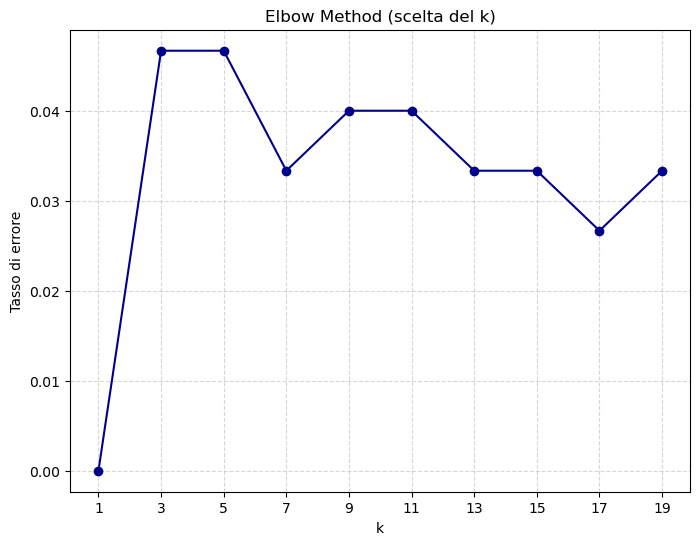

In [9]:
plt.figure(figsize=(8,6))
plt.plot(k_range_odd, errore_rate, marker="o", linestyle="-",color="darkblue")
plt.title("Elbow Method (scelta del k)")
plt.xlabel("k")
plt.ylabel("Tasso di errore")
plt.xticks(k_range_odd)
plt.grid(True,linestyle="--",alpha=0.5)
plt.show()

k=7

- Addestrare KNeighbordClassifier con il k trovato

In [11]:
best_k=7

knn_final=KNeighborsClassifier(n_neighbors=best_k)
#prendo solo le prime due feature
feature_0=0
feature_1=1
#faccio un dataframe di 2 dimensioni
X_2d=X_scaled[:,[feature_0,feature_1]]
#print(X_2d)

knn_final.fit(X_2d,y)
y_pred=knn_final.predict(X_2d)

- Utilizzare le prime due feature per creare una numpy.mesgrid e plottare i decion boundary (regioni di classificazione), differenziate per colore

In [12]:
x_min, x_max = X_2d[:, 0].min() - 0.5, X_2d[:, 0].max() + 0.5 #trovo il minimo ed il massimo ed aggiungo uno spazio (0.5)
y_min, y_max = X_2d[:, 1].min() - 0.5, X_2d[:, 1].max() + 0.5 #trovo il minimo ed il massimo ed aggiungo uno spazio (0.5)
#gridgli rettangolare, in cui i punti saranno equispaziati
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))
Z=knn_final.predict(np.c_[xx.ravel(), yy.ravel()])
Z=Z.reshape(xx.shape)

C:\Users\uberti\AppData\Local\Temp\ipykernel_31520\45705962.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


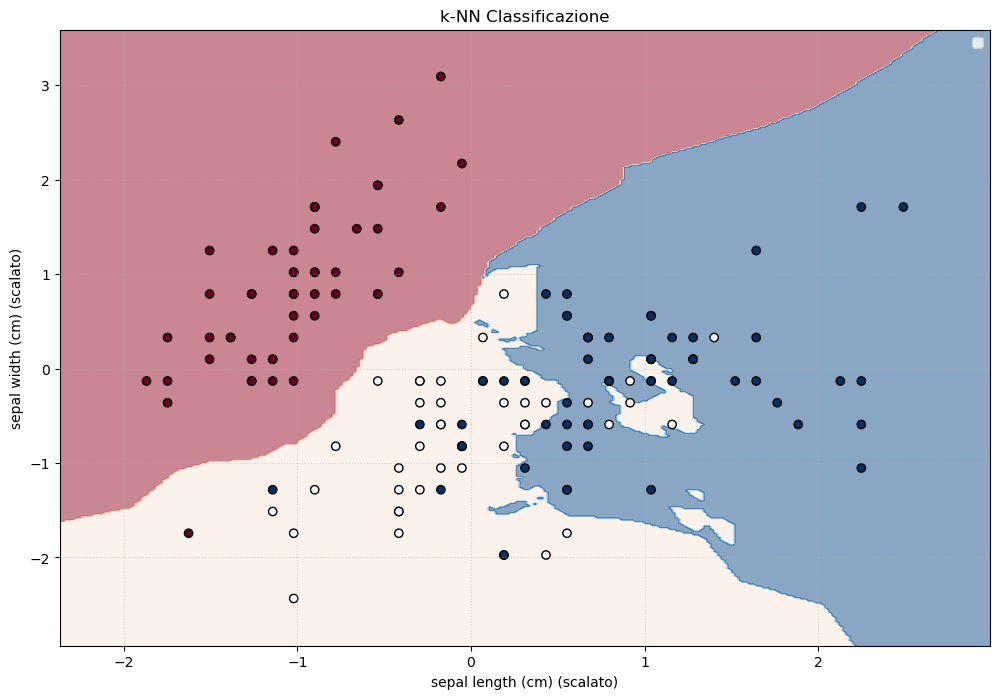

In [13]:
plt.figure(figsize=(12, 8))
plt.contourf(xx, yy, Z, alpha=0.5, cmap=plt.cm.RdBu)  #confini decisionali

plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y, edgecolors='k', cmap=plt.cm.RdBu)

plt.title(f"k-NN Classificazione")
plt.xlabel(f"{data.feature_names[feature_0]} (scalato)")
plt.ylabel(f"{data.feature_names[feature_1]} (scalato)")

plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())

plt.xticks()
plt.yticks()
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend()
plt.show()

- Calcolare il numero di label correttamente ed erroneamente assegnate, poi l'accuratezza.

In [14]:
tot_samples = len(y)

correct_arr = (y_pred == y)
correct_count = np.sum(correct_arr)
incorrect_count = tot_samples - correct_count
print(f"TOT:\t{tot_samples}")
print(f"Corretti:\t{correct_count}")
print(f"Incorretti:\t{incorrect_count}")

accuracy = correct_count /tot_samples
print(f"ACCURACY:\t{accuracy * 100:.2f}%")


TOT:	150
Corretti:	129
Incorretti:	21
ACCURACY:	86.00%
